# Домашнее задание 5. Градиентный спуск. (10 баллов + 2 балла бонус)

В этом домашнем задании вы реализуете градиентный спуск для линейной регрессии, а также изучите, как он ведёт себя при разных параметрах и с разными функциями потерь.

Правила:

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания всем участникам нарушения будет выставлено 0 баллов, независимо от того, кто у кого списывал.

* Старайтесь сделать код максимально оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, рассмотренных в курсе.  

In [1]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np

## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — **Mean Squared Error (MSE)**:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов.

Чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его **не нужно**. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса.
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять градиент функции потерь по параметрам модели.

In [2]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`.

Он должен вычислять лосс и градиент по формулам наверху.

In [3]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        # -- YOUR CODE HERE -- ( ⚆ ω ⚆)
        # Вычислите значение функции потерь при помощи X, y и w и верните его
        err = X @ w - y
        return np.mean(err ** 2)


    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        # -- YOUR CODE HERE -- =^･ω･^=
        # Вычислите значение вектора градиента при помощи X, y и w и верните его
        err = X @ w - y
        return (2 / X.shape[0]) * (X.T @ err) 

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [4]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^{t+1} = w^{t} - \eta \nabla_{w} Q(w^{t}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`.

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше, и возвращать
траекторию спуска (список из новых значений весов на каждом шаге).

In [5]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    # -- YOUR CODE HERE -- (ﾉ´ з `)ノ
    res = []
    w_t = w_init.copy()
    for i in range(n_iterations):
        w_t = w_t - lr * loss.calc_grad(X, y, w_t)
        res.append(w_t.copy())
    return res

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории.

In [6]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [7]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

155.26258214351938
0.8670644395649493


In [8]:
#чуть-чуть поменяла, чтобы отображалось красиво
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss, lr: float = 0, batch_size: int = 0, p:float = 0, ax = None):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)
    #поменяли 
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(15, 6))
    else:
        fig = ax.figure
    
    if p != 0:
        ax.set_title(f"p={p}")
    elif lr == 0 and batch_size == 0:
        ax.set_title("GD trajectory")
    elif lr != 0 and batch_size == 0:
        ax.set_title(f"lr={lr}")
    elif lr == 0 and batch_size != 0:
        ax.set_title(f"batch_size={batch_size}")
    else:
        ax.set_title(f"lr={lr}, batch_size={batch_size}")

    ax.set_xlabel(r"$w_1$")
    ax.set_ylabel(r"$w_2$")
    # чтобы не вытягивалось
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect("equal")

    # Отображение уровня функции потерь
    CS = ax.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, ax=ax, shrink=0.8, extend="both")

    # Отображение траектории спуска
    ax.scatter(w_list[:, 0], w_list[:, 1])
    ax.plot(w_list[:, 0], w_list[:, 1])
    
    if ax is None:
        plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте четыре и более различных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска.

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`.
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1.

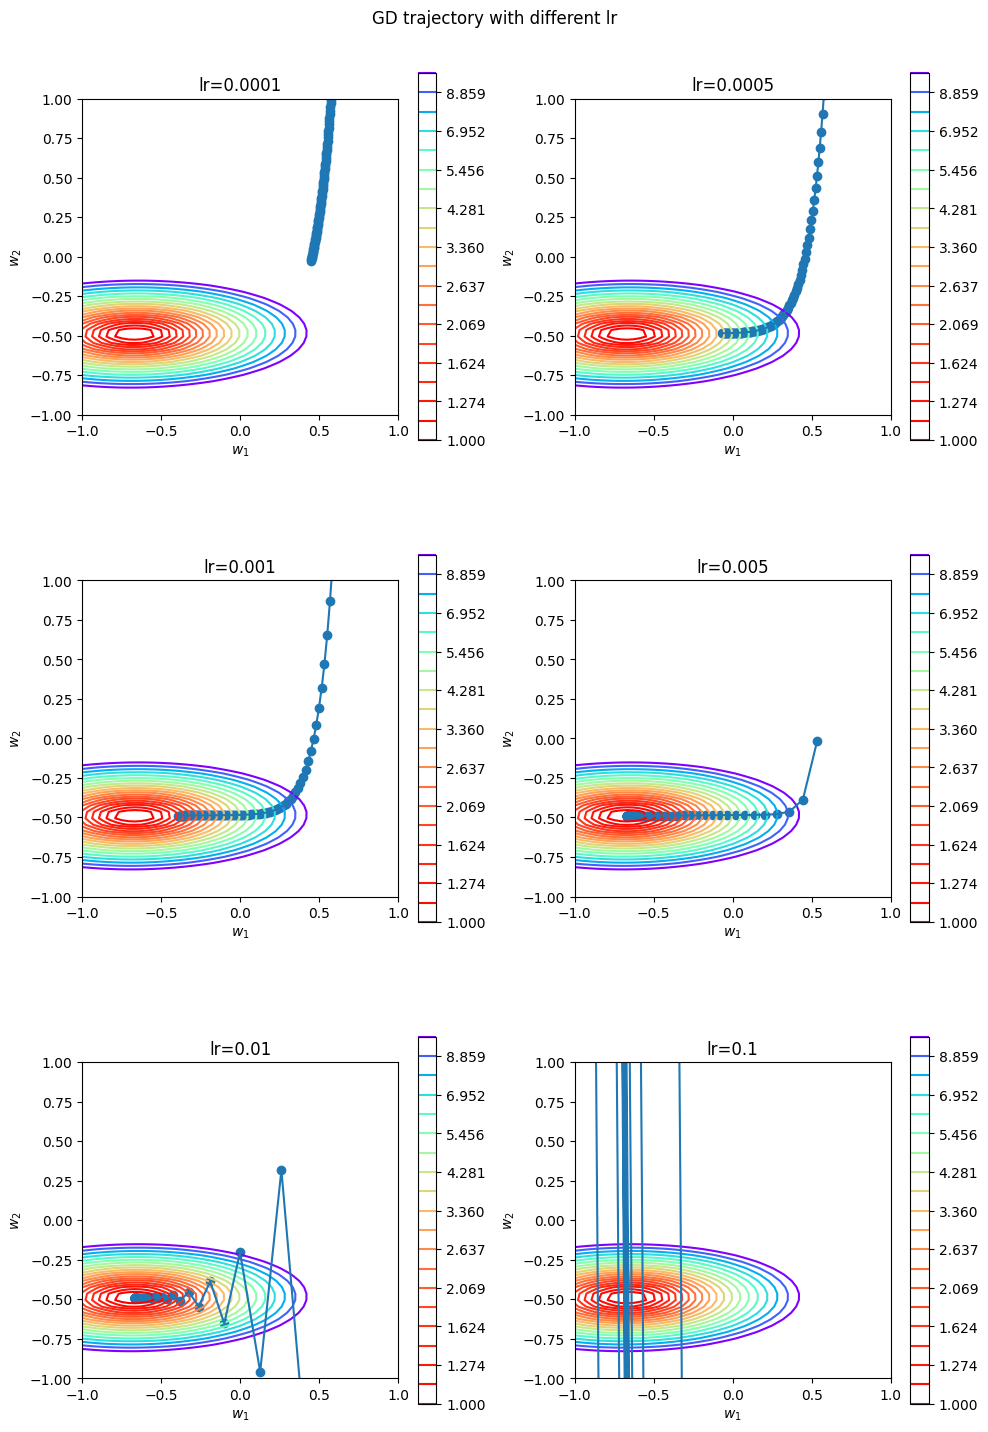

In [10]:
# -- YOUR CODE HERE -- ٩(⁎❛ᴗ❛⁎)۶
lrs = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.1]
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
axes = axes.ravel()
fig.suptitle("GD trajectory with different lr")

for i in range(len(lrs)):
    w_list = gradient_descent(w_init, X, y, loss, lrs[i], 100)
    ax = axes[i]
    plot_gd(w_list, X, y, loss, lr=lrs[i], ax=ax)
plt.tight_layout()
plt.show()
# При малегьких lr (0.0001-0.001) градиентный спуск сходится плавно, но медленно (не хватает итераций, чтобы дойти до минимума)
# При больших lr (0.01-0.1) шаги получаются очень большими, и мы иногда не попадаем в локальный минимум -> веса начинают расти в обратном направлении
# Лучшим (в данном случае) будет lr=0.005 - успевает сойтись к минимуму, при этом не делает слишком больших шагов в начале

Теперь реализуем стохастический градиентный спуск.

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`.

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [11]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    # -- YOUR CODE HERE -- (＠_＠)
    res = []
    w_t = w_init.copy()
    for i in range(n_iterations):
        batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]
        w_t = w_t - lr * loss.calc_grad(X_batch, y_batch, w_t)
        res.append(w_t.copy())
    return res

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших `batch_size`?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

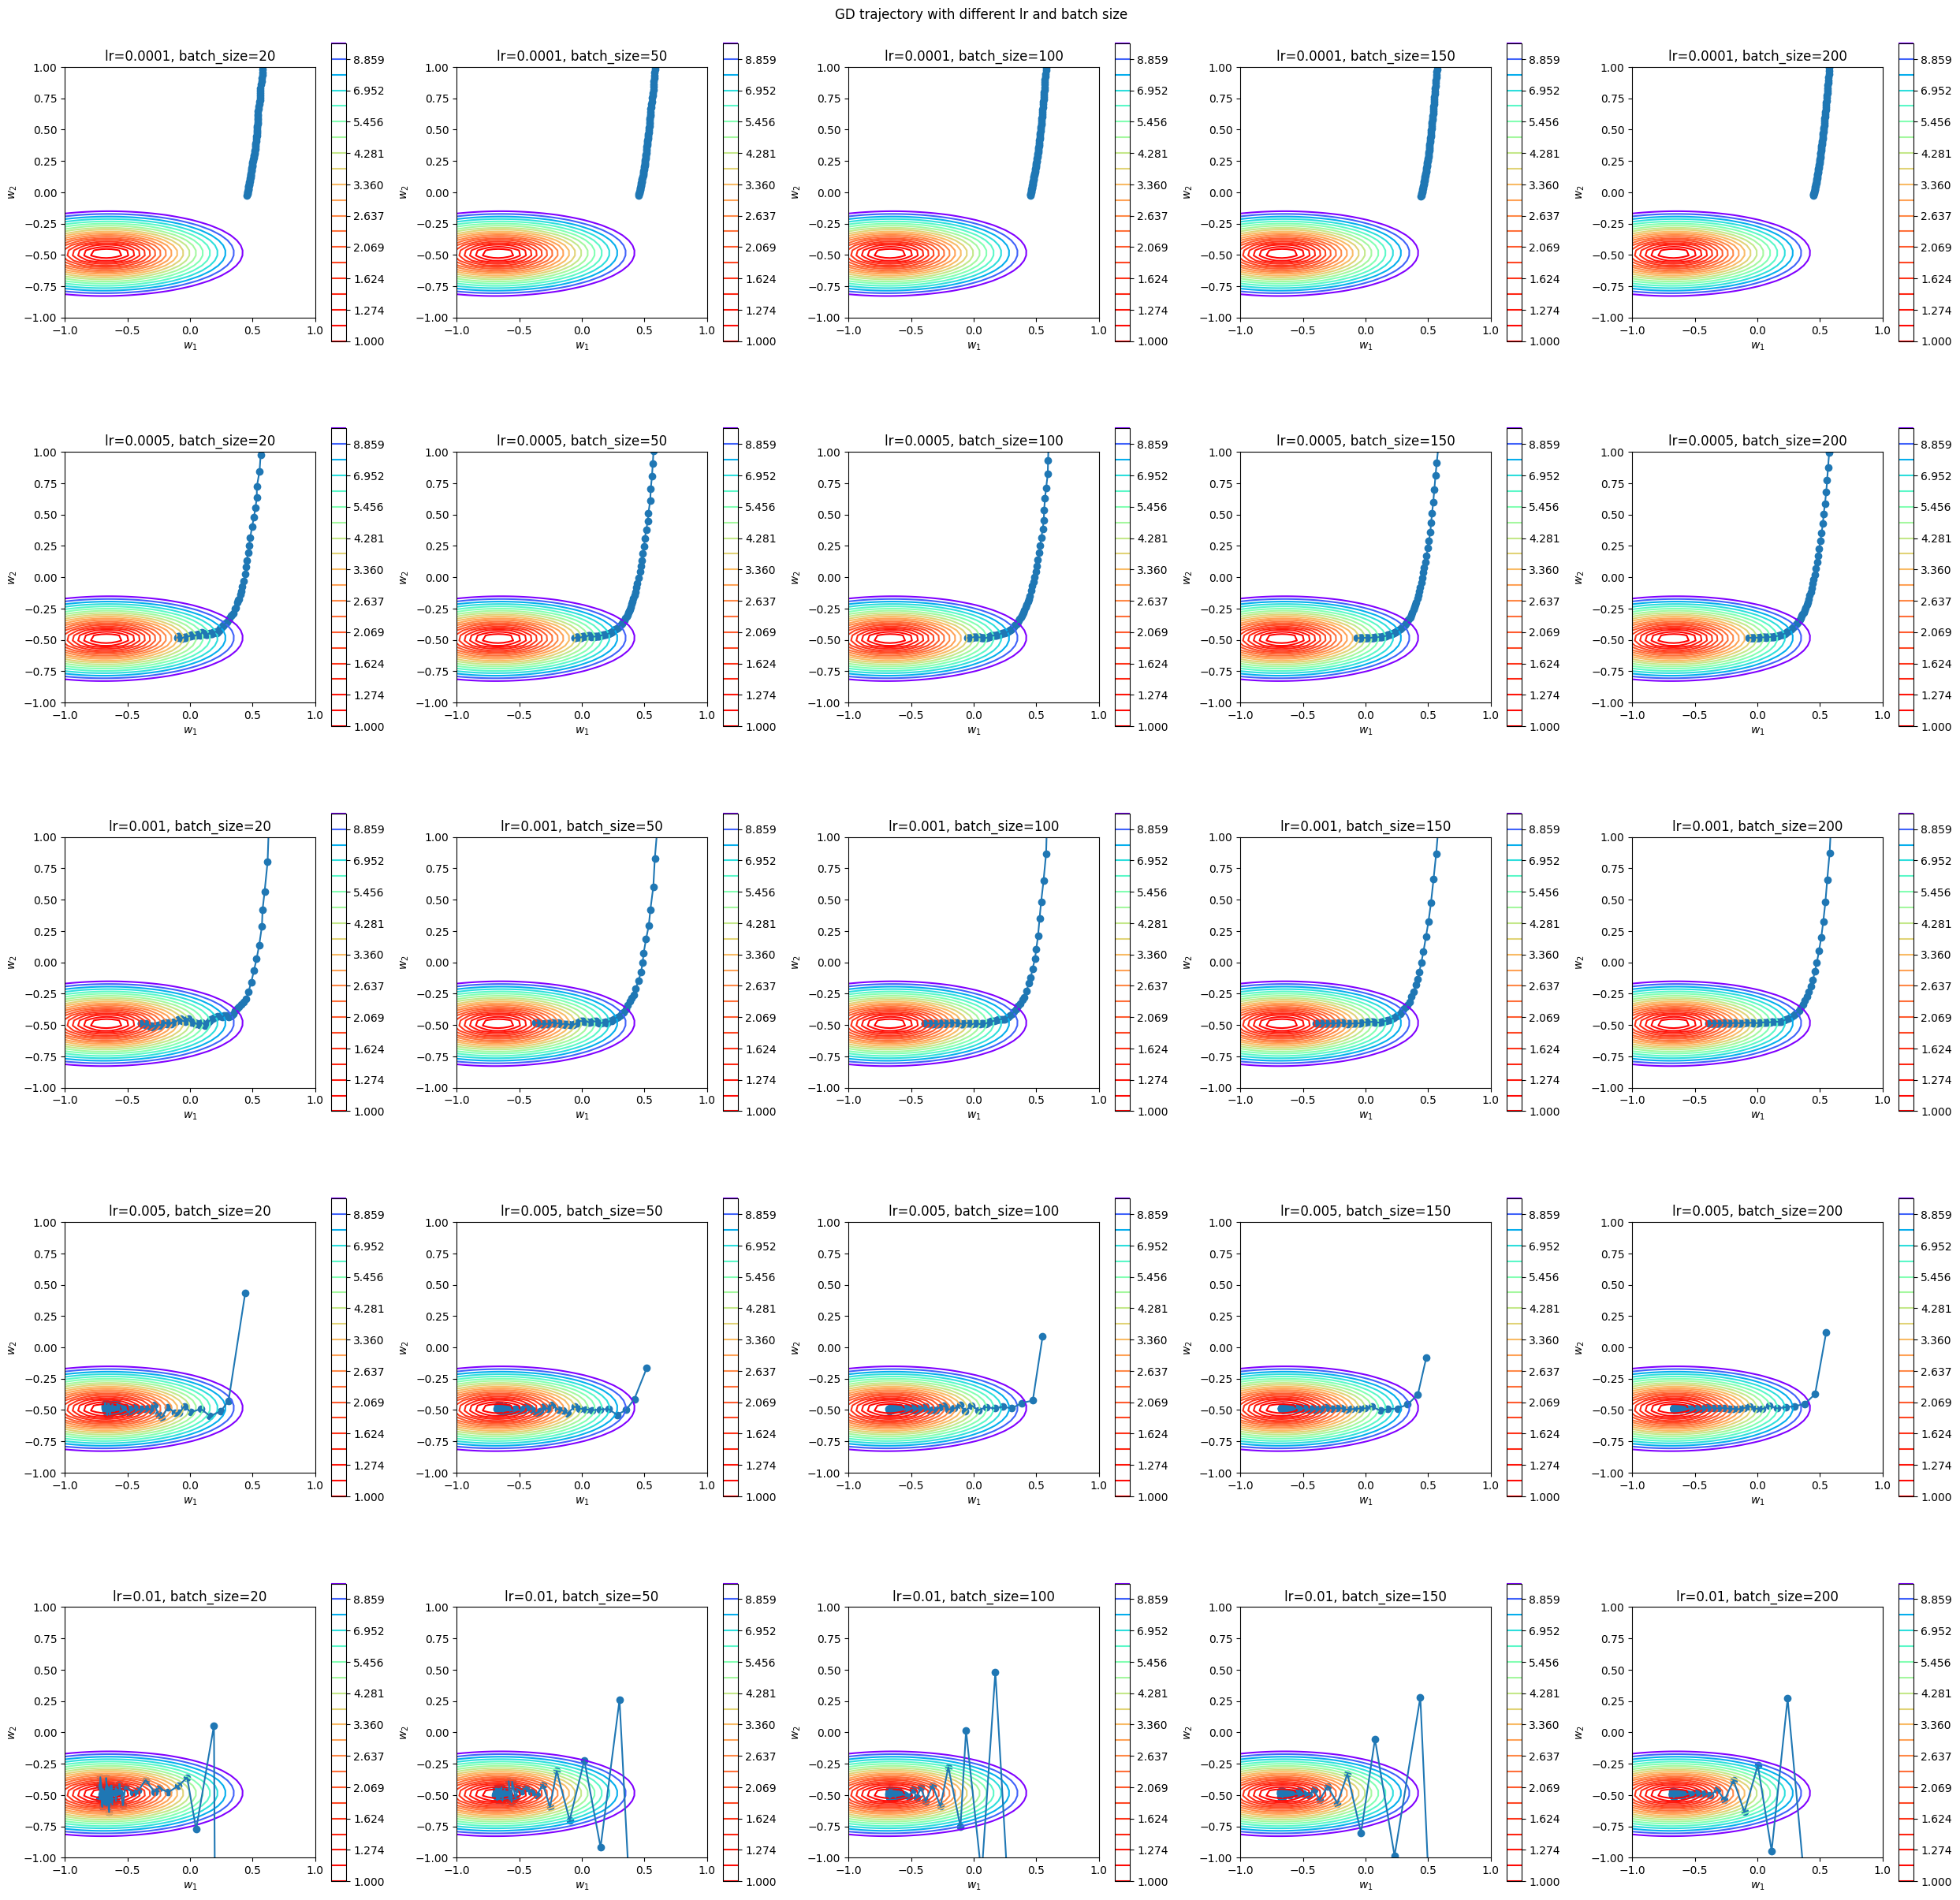

In [ ]:
# -- YOUR CODE HERE -- ٩(⁎❛ᴗ❛⁎)۶
lrs = [0.0001, 0.0005, 0.001, 0.005, 0.01]
batch_sizes = [20, 50, 100, 150, 200]
fig, axes = plt.subplots(len(lrs), len(batch_sizes), figsize=(25, 25))
fig.suptitle("GD trajectory with different lr and batch size")
for i in range(len(lrs)):
    for j in range(len(batch_sizes)):
        w_list = stochastic_gradient_descent(w_init, X, y, loss, lrs[i], batch_sizes[j], 100)
        ax = axes[i, j]
        plot_gd(w_list, X, y, loss, lr=lrs[i], batch_size=batch_sizes[j], ax=ax)
plt.tight_layout()
plt.show()
# При больших batch_size спуск становится более плавным, тогда как при меньших значениях он колеблется сильнее + "метается" в окресностях минимума из-за того, что минимум для небольшой выборки сильно отклоняется от минимума для всех данных
# Для маленьких lr спуск не успевает сойтись (размер batch_size не так сильно влияет), для слишком болших lr колебания также остаются
# Лучшими (в данном случае) будут lr=0.005 и batch_size не менее 100 (1/3 выборки и более) -> достаточная скорость сходимости и небольшое количество шума

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы точнее этого минимума достигнуть и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [13]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - параметр величины шага, на который нужно домножать градиент
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    # -- YOUR CODE HERE -- ¯\_(ツ)_/¯
    s0 = 1
    res = []
    w_t = w_init.copy()
    for t in range(1, n_iterations + 1):
        batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]
        lr_t = lr * ((s0 / (s0 + t)) ** p)
        w_t = w_t - lr_t * loss.calc_grad(X_batch, y_batch, w_t)
        res.append(w_t.copy())
    return res

**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска. Что происходит при маленьком или большом значении p?

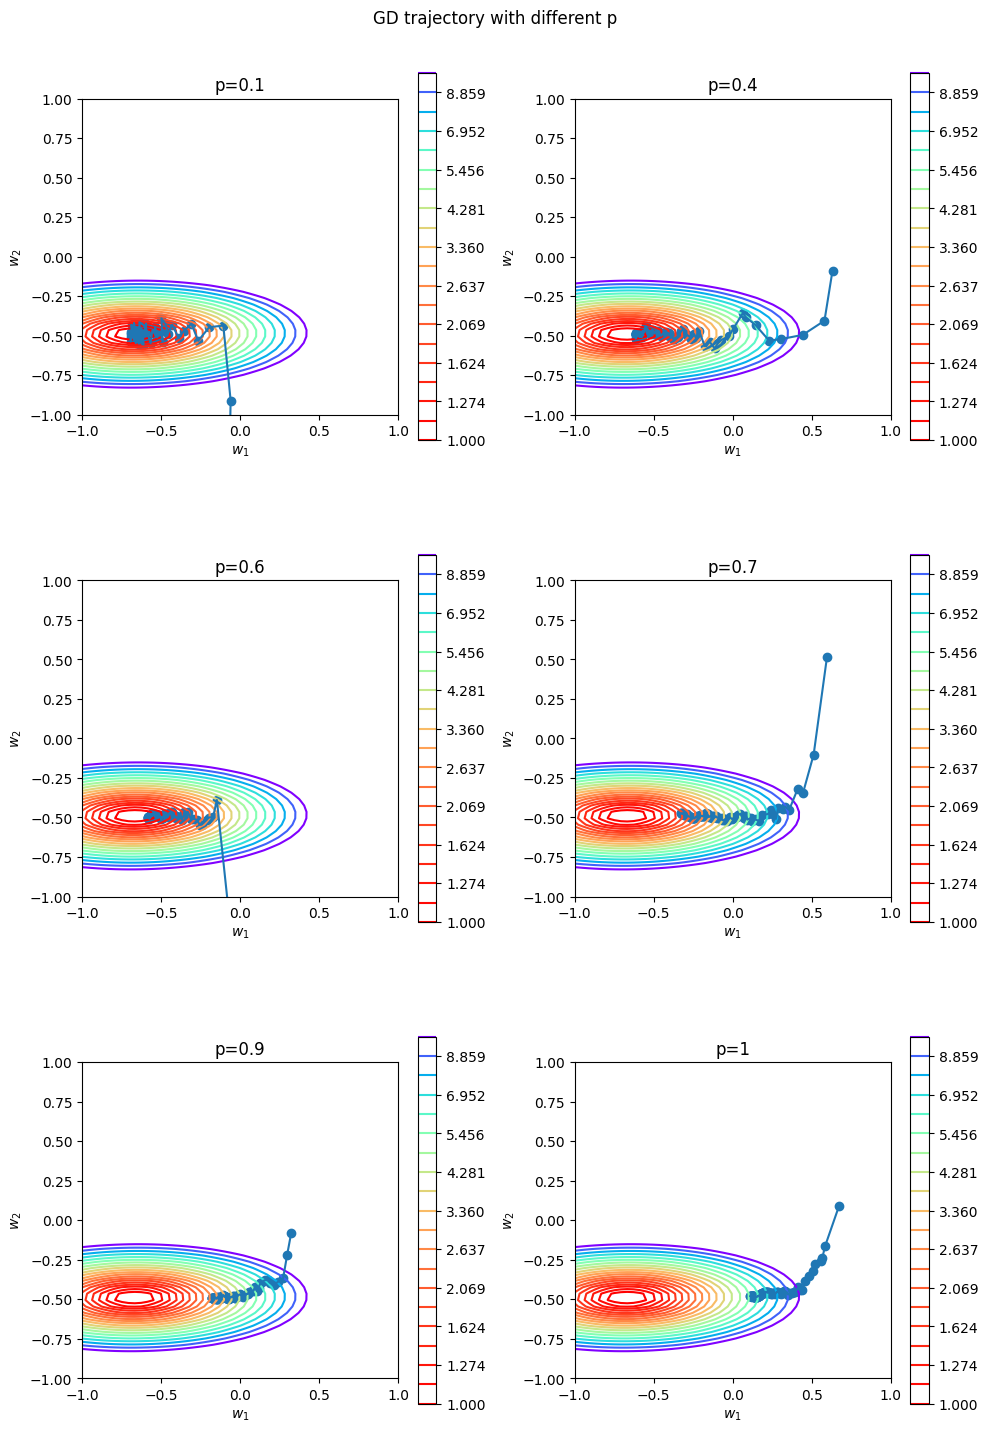

In [ ]:
# -- YOUR CODE HERE -- [✖‿✖]
lr = 0.01
batch_size = 10
p = [0.1, 0.4, 0.6, 0.7, 0.9, 1]

fig, axes = plt.subplots(3, 2, figsize=(10, 15))
axes = axes.ravel()
fig.suptitle("GD trajectory with different p")
for i in range(len(p)):
    w_list = stochastic_gradient_descent(w_init, X, y, loss, lr=lr, batch_size=batch_size, p=p[i], n_iterations=100)
    ax = axes[i]
    plot_gd(w_list, X, y, loss, lr=lr, batch_size=batch_size, p=p[i], ax=ax)
plt.tight_layout()
plt.show()

# При маленьких p шаги в конце спуска получаются слишком большими -> спуск достигает окресности минимума, но не можем точно остановиться в нём
# При больших p шаг затухает очень быстро -> спуск не успевает сойтись к минимуму из-за небольшого шага в конце
# Оптимальным (в данном случае) будет p=0.4, так как спуск достаточно быстро доходит до минимума, при этом шаг не успевает уменьшиться слишком сильно -> доходим до минимума

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

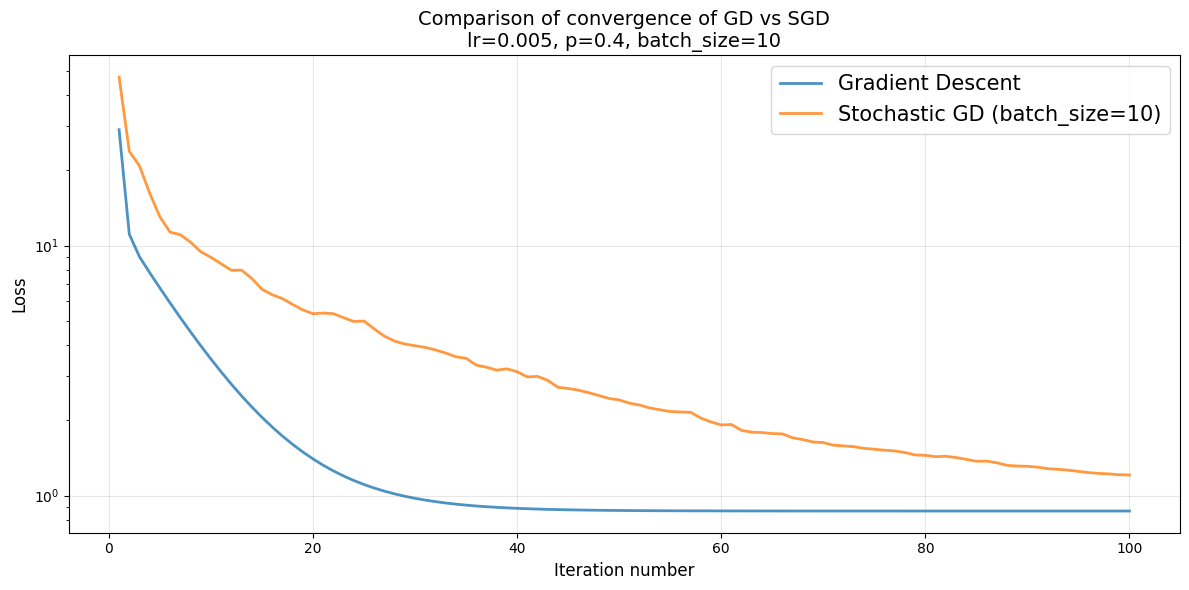

In [28]:
# -- YOUR CODE HERE -- ┌(ಠ_ಠ)┘
batch_size = 10
lr = 0.005
p = 0.4
n_iterations = 100
w_list_calssic = gradient_descent(w_init, X, y, loss, lr=lr, n_iterations=n_iterations)
w_list_sgd = stochastic_gradient_descent(w_init, X, y, loss, lr=lr, batch_size=batch_size, p=p, n_iterations=n_iterations)
loss = MSELoss()
loss_classic = np.apply_along_axis(lambda w: loss.calc_loss(X, y, w), axis=1, arr=w_list_calssic)
loss_sgd = np.apply_along_axis(lambda w: loss.calc_loss(X, y, w), axis=1, arr=w_list_sgd)

plt.figure(figsize=(12, 6))
iterations = np.arange(1, n_iterations + 1)
plt.plot(iterations, loss_classic, label='Gradient Descent', linewidth=2, alpha=0.8)
plt.plot(iterations, loss_sgd, label=f'Stochastic GD (batch_size={batch_size})', linewidth=2, alpha=0.8)
    
plt.xlabel('Iteration number', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title(f'Comparison of convergence of GD vs SGD\nlr={lr}, p={p}, batch_size={batch_size}', fontsize=14)
plt.legend(fontsize=15)
plt.grid(True, alpha=0.3)
    
plt.yscale('log')
    
plt.tight_layout()
plt.show()

# SGD сходится быстрее снижает ошибку, т.к. считается по части выборки. При этом GD сходится быстрее, т.к. подсчёт более точный
# При увеличении итераций разница сокращается быстрее
    

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`.

В методе `predict` мы будем применять нашу регрессию к датасету.

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`.

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [29]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        # -- YOUR CODE HERE -- ʕ•ᴥ•ʔ
        self.w = np.zeros(X.shape[1])
        self.w = gradient_descent(self.w, X, y, self.loss, self.lr)[-1]
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        # -- YOUR CODE HERE -- ٩(⁎❛ᴗ❛⁎)۶
        return X @ self.w

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [30]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [32]:
import pandas as pd

X_raw = pd.read_csv(
    "cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)
X_raw = X_raw[~X_raw[26].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [33]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

In [35]:
# -- YOUR CODE HERE -- =^･ω･^=
# 1. Делим на тренировочную и тестовую выборки
from sklearn.model_selection import train_test_split

y_bin = pd.qcut(y, q=10, labels=False) # фиксированное число бинов
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.3, random_state=42, stratify=y_bin)

# 2. Заполняем пропуски
print(f"Число пропусков в X_raw: {X_raw.isna().sum()}") # пропуски есть
print(f"Число пропусков в таргете: {y.isna().sum()}") # пропусков нет

# преобразуем имена столбцов в строки
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

# заполним пропуски в числовых признаках средним значением
from sklearn.impute import SimpleImputer
numeric_mask = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_mask = X_train.select_dtypes(include=['object', 'string']).columns

imputer = SimpleImputer(strategy="mean")
imputer.fit(X_train[numeric_mask])

X_test.loc[:, numeric_mask] = imputer.transform(X_test[numeric_mask])
X_train.loc[:, numeric_mask] = imputer.transform(X_train[numeric_mask])
# заполним пропуски в категориальных признаках модой
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_imputer.fit(X_train[categorical_mask])
X_test[categorical_mask] = cat_imputer.transform(X_test[categorical_mask])
X_train[categorical_mask] = cat_imputer.transform(X_train[categorical_mask])
print(f"Теперь число пропусков в данных: {X_test.isna().sum().sum() + X_train.isna().sum().sum()}") # пропусков нет

# 3. Нормальзуем числовые признаки
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train[numeric_mask])
X_train[numeric_mask] = scaler.transform(X_train[numeric_mask])
X_test[numeric_mask] = scaler.transform(X_test[numeric_mask])

# 4. Закодируем категориальные призаки (one-hot)
from sklearn.preprocessing import OneHotEncoder

categorical_cols = categorical_mask.tolist()
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[categorical_cols])

train_encoded = encoder.transform(X_train[categorical_cols])
test_encoded = encoder.transform(X_test[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)

X_train_cat = pd.DataFrame(train_encoded, columns=encoded_cols, index=X_train.index)
X_test_cat = pd.DataFrame(test_encoded, columns=encoded_cols, index=X_test.index)
    
X_train = pd.concat([X_train[numeric_mask], X_train_cat], axis=1)
X_test = pd.concat([X_test[numeric_mask], X_test_cat], axis=1)

# Полюбуемся красотой
X_train.head()


Число пропусков в X_raw: 1      0
2     37
3      0
4      0
5      0
6      2
7      0
8      0
9      0
10     0
11     0
12     0
13     0
14     0
15     0
16     0
17     0
18     0
19     4
20     4
21     0
22     2
23     2
24     0
25     0
dtype: int64
Число пропусков в таргете: 0
Теперь число пропусков в данных: 0


c:\Users\YOGA\OneDrive\Desktop\codes\all python codes\иадик\myenv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,1,2,10,11,12,13,14,17,19,20,...,16_six,16_three,16_two,18_2bbl,18_4bbl,18_idi,18_mfi,18_mpfi,18_spdi,18_spfi
149,-0.731504,-1.489644,-0.480893,-0.338109,-1.073745,2.231410,-0.538961,-0.856371,-1.007201,-0.696501,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
86,0.062376,0.161597,-0.681165,-0.692500,-0.979939,0.305099,-1.323546,-0.730169,-0.634969,0.132966,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
90,0.062376,-0.647835,-0.681165,-0.297838,-0.979939,-0.113664,-1.052654,-0.730169,-0.634969,0.132966,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
140,-0.731504,-0.680212,-0.263931,-0.152860,-0.229490,0.221346,-0.328267,-0.452524,1.114523,-1.940701,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
153,-0.731504,-1.036362,-0.480893,-0.611956,-0.698520,-0.406799,-0.882092,-0.704928,-0.486076,-0.696501,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [36]:
# -- YOUR CODE HERE -- (ﾉ´ з `)ノ
linear_regression.fit(X_train, y_train)
linear_regression.w # веса

array([-1202.86759668, -1021.83716076,  1319.08179274, -2169.76691706,
        1605.40717992, -1305.08858656,  3345.93359658,  4118.57473075,
       -1132.9541072 ,  -464.69899828, -1460.36124948,   798.16722884,
        1164.95734631,   163.37402457,   915.93598525,  6164.98124201,
        7690.96613916, -5089.49695588, -3817.34081975, -2323.873802  ,
       -3703.29151087,  -659.20894506,  1798.49973327, -4253.35349251,
       -3410.43613979,  -505.0246452 , -3588.68960097, -4991.80457562,
        4677.5076531 ,  -928.30410365,  5162.52817211, -3670.47013827,
       -2883.46684147,  1208.88298394, -3767.41704796,  4580.62214709,
        1997.03476918,   530.90299568, -2280.84644577, -3512.09311988,
       -2952.16135146, -2843.88070469, -1270.83869531,  1613.5997568 ,
        4677.5076531 ,  -159.34940592,  -633.98519726,  1007.03751483,
       -5501.77772784,   447.69917766, -6527.10324722, -3185.95804933,
       -4336.72199971,  3429.34019505,   447.69917766,  2740.67074083,
      

**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [37]:
from sklearn.metrics import mean_squared_error

# -- YOUR CODE HERE -- ( ⚆ ω ⚆)
y_pred_train = linear_regression.predict(X_train)
y_pred_test = linear_regression.predict(X_test)

print(f"MSE для train: {mean_squared_error(y_train, y_pred_train)}")
print(f"MSE для test: {mean_squared_error(y_test, y_pred_test)}")


MSE для train: 1735128.0396366653
MSE для test: 8167517.206129957


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации.

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`.

Он должен вычислять лосс и градиент по формулам выше.

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`.

In [38]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        # -- YOUR CODE HERE -- (´｡• ᵕ •｡`)
        # Вычислите значение функции потерь при помощи X, y и w и верните его
        err = (X @ w) - y
        mse = np.mean(err ** 2)
        return mse + self.coef * np.sum(w[:-1]**2)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        # -- YOUR CODE HERE -- (￢_￢)
        # Вычислите значение вектора градиента при помощи X, y и w и верните его
        err = X @ w - y
        reg_part = 2 * self.coef * w
        reg_part[-1] = 0
        return (2 / len(y)) * (X.T @ err) + reg_part
        

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [39]:
linear_regression_l2 = LinearRegression(MSEL2Loss(0.1))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [ ]:
# -- YOUR CODE HERE -- (＠_＠)
linear_regression_l2.fit(X_train, y_train)

y_pred_train_0 = linear_regression_l2.predict(X_train)
y_pred_test_0 = linear_regression_l2.predict(X_test)

mse_train_0 = mean_squared_error(y_train, y_pred_train_0)
mse_test_0 = mean_squared_error(y_test, y_pred_test_0)
print(f"MSE для train: {mse_train_0:.4f}")
print(f"MSE для test: {mse_test_0:.4f}")
print()

# поделим тренировочную выборку на тренировочную и валидационную
y_bin = pd.qcut(y_train, q=8, labels=False)
X_train_pt, X_val, y_train_pt, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=52, stratify=y_bin)

coefs = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
best_coef = None
best_mse = 10**100
print("coef\t| train_mse\t| val_mse")
for coef in coefs:
    linear_regression_l2 = LinearRegression(MSEL2Loss(coef))
    linear_regression_l2.fit(X_train_pt, y_train_pt)

    y_pred_train = linear_regression_l2.predict(X_train_pt)
    mse_l2_train = mean_squared_error(y_train_pt, y_pred_train)

    y_pred_val = linear_regression_l2.predict(X_val)
    mse_l2_val = mean_squared_error(y_val, y_pred_val)
    print(f'{coef}\t|{mse_l2_train:.4f}\t|{mse_l2_val:.4f}')

    if mse_l2_val < best_mse:
        best_mse = mse_l2_val
        best_coef = coef
print(f'Best coef: {best_coef}') # лучшим оказался коэффициент 0.01
print()

# теперь сравним с регрессией без регуляризации
print("reg_type| mse_train\t| mse_test")

# без регуляризации
y_pred_train = linear_regression.predict(X_train)
y_pred_test = linear_regression.predict(X_test)
print(f"MSE\t| {mean_squared_error(y_train, y_pred_train):.4f}\t| {mean_squared_error(y_test, y_pred_test):.4f}")

#с регуляризацией
linear_regression_l2 = LinearRegression(MSEL2Loss(best_coef))
linear_regression_l2.fit(X_train, y_train)
y_pred_train = linear_regression_l2.predict(X_train)
y_pred_test = linear_regression_l2.predict(X_test)
print(f'MSE_L2\t| {mean_squared_error(y_train, y_pred_train):.4f}\t| {mean_squared_error(y_test, y_pred_test):.4f}')
# Лучше оказался MSE_L2


MSE для train: 5808102.3718
MSE для test: 6475074.0629

coef	| train_mse	| val_mse
0.0001	|1203829.2283	|11070600.0307
0.0005	|1276852.5609	|8332206.0629
0.001	|1347664.8355	|7429062.2584
0.005	|1877173.7149	|6373035.7292
0.01	|2387699.1224	|6321667.7955
0.05	|4364601.1998	|6416179.2886
0.1	|5703812.1561	|6818817.5609
Best coef: 0.01

reg_type| mse_train	| mse_test
MSE	| 1735128.0396	| 8167517.2061
MSE_L2	|2755788.0541	|7100262.9437


В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`.

Он должен вычислять лосс и градиент по формулам выше.

In [41]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        # -- YOUR CODE HERE -- (っ˘ڡ˘ς)
        # Вычислите значение функции потерь при помощи X, y и w и верните его
        err = X @ w - y
        res = np.where(np.abs(err) < self.eps, 0.5 * (err ** 2), self.eps * (np.abs(err) - 0.5 * self.eps))
        return np.mean(res)


    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        # -- YOUR CODE HERE -- ٩(ˊ〇ˋ*)و
        # Вычислите значение вектора градиента при помощи X, y и w и верните его
        err = X @ w - y
        res = np.where(np.abs(err) < self.eps, err, self.eps * np.sign(err))
        return X.T @ res / len(y)

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [42]:
# -- YOUR CODE HERE -- # (⌐■_■)
# найдём лучшее eps
epsilons = [20, 30, 35, 45, 50, 60, 70, 80, 100]
best_mse = 10**100
best_eps = None

print("eps\t|train_mse\t|val_mse")

for eps in epsilons:
    linear_regression_hl = LinearRegression(HuberLoss(eps))
    linear_regression_hl.fit(X_train_pt, y_train_pt)

    y_pred_train = linear_regression_hl.predict(X_train_pt)
    mse_hl_train = mean_squared_error(y_train_pt, y_pred_train)

    y_pred_val = linear_regression_hl.predict(X_val)
    mse_hl_val = mean_squared_error(y_val, y_pred_val)
    print(f'{eps}\t|{mse_hl_train:.4f}\t|{mse_hl_val:.4f}')

    if mse_hl_val < best_mse:
        best_mse = mse_hl_val
        best_eps = eps
print(f'Best eps: {best_eps}') # лучшим оказался eps = 30
print()

# сравнение

print("reg_type\t| mse_train\t| mse_test")

linear_regression = LinearRegression(MSELoss())
linear_regression.fit(X_train, y_train)
y_pred_train = linear_regression.predict(X_train)
y_pred_test = linear_regression.predict(X_test)
print(f"MSE\t\t| {mean_squared_error(y_train, y_pred_train):.4f}\t| {mean_squared_error(y_test, y_pred_test):.4f}")

linear_regression_hl = LinearRegression(HuberLoss(best_eps))
linear_regression_hl.fit(X_train, y_train)
y_pred_train = linear_regression_hl.predict(X_train)
y_pred_test = linear_regression_hl.predict(X_test)
print(f'Hyberloss\t| {mean_squared_error(y_train, y_pred_train):.4f}\t| {mean_squared_error(y_test, y_pred_test):.4f}')
# Hyberloss оказался лучше

eps	|train_mse	|val_mse
20	|3404032.5768	|9016155.9318
30	|2770275.0888	|8394327.0248
35	|2644000.1433	|8819403.6010
45	|2411579.0814	|9204929.7323
50	|2335237.9142	|9385738.0422
60	|2251844.4506	|9804309.4696
70	|2244333.6056	|10092498.2949
80	|2238623.7155	|10276442.6238
100	|2204361.6866	|10294379.1240
Best eps: 30

reg_type	| mse_train	| mse_test
MSE		| 1735128.0396	| 8167517.2061
Hyberloss	| 3341464.0500	| 6300969.7082


**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2025 в ячейку ниже:

In [ ]:
# -- YOUR MEME HERE -- ╰( ͡° ͜ʖ ͡° )つ▬▬ι═══════  bzzzzzzzzzz

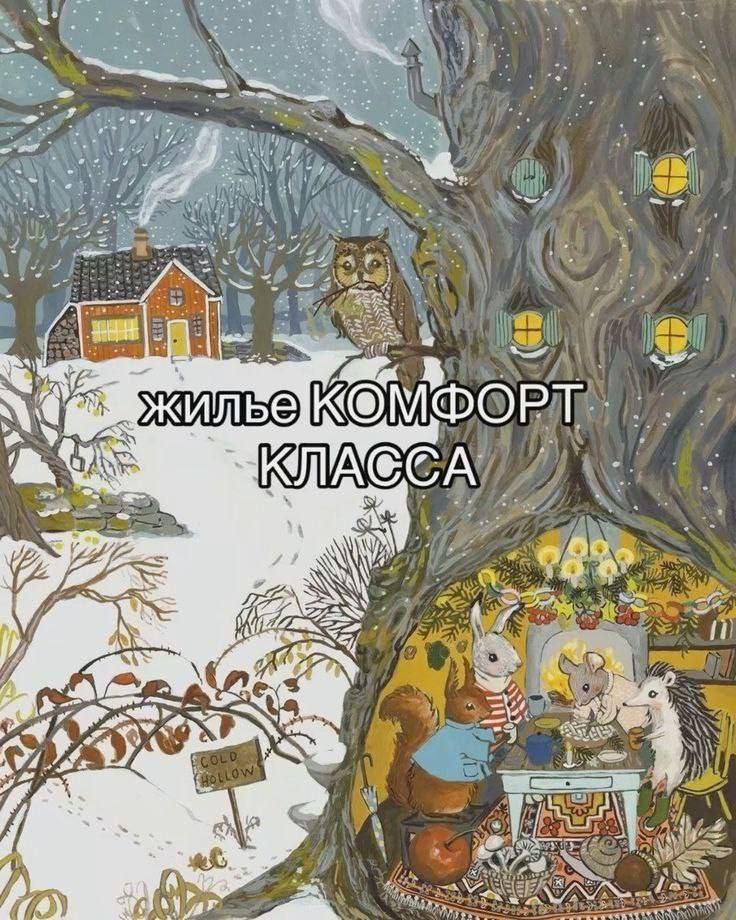

### БОНУС (2 балла)

Градиентный спуск — далеко не единственный метод оптимизации.
Другой очень известный метод называется ["Алгоритм имитации отжига"](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B8%D0%BC%D0%B8%D1%82%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D1%82%D0%B6%D0%B8%D0%B3%D0%B0). Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.

**Задание (2 балла)**:
Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии.

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределения с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3.
Это может выглядеть, например, так:
```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

In [ ]:
# -- YOUR CODE HERE -- ʕ•ᴥ•ʔ